<h1><b>E-Commerce Sales Analysis</b></h1>
<b>Project Story:</b>

This project analyzes real-world e-commerce sales data from Kaggle to uncover meaningful business insights. As part of my 15-Day Data & Business Analysis Challenge, I explored how sales, profit, and discount patterns vary across categories, regions, and time periods. Using Python, Pandas, and Seaborn, I transformed raw transactional data into actionable insights that can help businesses understand performance trends, identify profitable products, and optimize discount strategies for better decision-making.
<br><br><b>Project Overview:</b><br>
The E-Commerce Sales Analysis project focuses on exploring, cleaning, and analyzing an online retail dataset to reveal sales performance and profitability patterns. It includes examining category-wise and regional trends, evaluating the impact of discounts on profits, and identifying the most and least profitable segments. Through data-driven storytelling and visualization, the project demonstrates how data analytics can turn raw sales data into valuable business intelligence.

<h3><b>Import Libraries

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

<h3><b>Load Dataset

In [2]:
df = pd.read_csv('ecommerce sales.csv')
df.info()
df.head(2)

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1000 entries, 0 to 999
Data columns (total 18 columns):
 #   Column          Non-Null Count  Dtype  
---  ------          --------------  -----  
 0   product_id      1000 non-null   int64  
 1   product_name    1000 non-null   object 
 2   category        1000 non-null   object 
 3   price           1000 non-null   float64
 4   review_score    1000 non-null   float64
 5   review_count    1000 non-null   int64  
 6   sales_month_1   1000 non-null   int64  
 7   sales_month_2   1000 non-null   int64  
 8   sales_month_3   1000 non-null   int64  
 9   sales_month_4   1000 non-null   int64  
 10  sales_month_5   1000 non-null   int64  
 11  sales_month_6   1000 non-null   int64  
 12  sales_month_7   1000 non-null   int64  
 13  sales_month_8   1000 non-null   int64  
 14  sales_month_9   1000 non-null   int64  
 15  sales_month_10  1000 non-null   int64  
 16  sales_month_11  1000 non-null   int64  
 17  sales_month_12  1000 non-null   in

,product_id,product_name,category,price,review_score,review_count,sales_month_1,sales_month_2,sales_month_3,sales_month_4,sales_month_5,sales_month_6,sales_month_7,sales_month_8,sales_month_9,sales_month_10,sales_month_11,sales_month_12
0,1,Product_1,Clothing,190.4,1.7,220,479,449,92,784,604,904,446,603,807,252,695,306
1,2,Product_2,Home & Kitchen,475.6,3.2,903,21,989,861,863,524,128,610,436,176,294,772,353


<h3><b>Data Cleaning</b></h3>

In [8]:
#Handle missing values
df.isnull().sum()
df.fillna(0, inplace=True)   
#Remove duplicates
df.drop_duplicates(inplace=True)
#Fix data types
#Ensure price, review_score, review_count are numeric
df["price"] = pd.to_numeric(df["price"], errors='coerce')
df["review_score"] = pd.to_numeric(df["review_score"], errors='coerce')
df["review_count"] = pd.to_numeric(df["review_count"], errors='coerce')

<h3><b>Feature Engineering</b></h3>
Create new meaningful columns

In [9]:
# Total yearly sales
df["total_sales"] = df[[f"sales_month_{i}" for i in range(1, 13)]].sum(axis=1)

# Average monthly sales
df["avg_monthly_sales"] = df["total_sales"] / 12

# Review impact (example metric)
df["review_impact"] = df["review_score"] * df["review_count"]

# High-performing product flag
df["high_performer"] = df["total_sales"] > df["total_sales"].quantile(0.75)


<h3><b>Descriptive Statistics

In [13]:
df.describe()

# Price and review stats
df["price"].agg(["min", "max", "mean"])

min       7.29000
max     499.86000
mean    247.67713
Name: price, dtype: float64

In [14]:
df["review_score"].agg(["mean"])

mean    3.0276
Name: review_score, dtype: float64

In [15]:
df["review_count"].agg(["sum", "mean"])

sum     526506.000
mean       526.506
Name: review_count, dtype: float64

In [16]:
# Sales statistics
df["total_sales"].agg(["sum", "mean", "max", "min"])

sum     6019912.000
mean       6019.912
max        9151.000
min        2972.000
Name: total_sales, dtype: float64

<h3><b>Data Filtering

In [17]:
# Top 10 selling products
df.nlargest(10, "total_sales")

# Products with low review scores
df[df["review_score"] < 3.0]

# Filter by category
df[df["category"] == "Electronics"]

,product_id,product_name,category,price,review_score,review_count,sales_month_1,sales_month_2,sales_month_3,sales_month_4,...,sales_month_7,sales_month_8,sales_month_9,sales_month_10,sales_month_11,sales_month_12,total_sales,avg_monthly_sales,review_impact,high_performer
6,7,Product_7,Electronics,33.75,3.8,632,565,140,539,244,...,896,965,447,66,32,516,5298,441.500000,2401.6,False
7,8,Product_8,Electronics,433.76,4.4,906,905,83,48,926,...,280,102,202,753,376,445,4769,397.416667,3986.4,False
8,9,Product_9,Electronics,302.55,2.0,848,809,693,419,106,...,42,992,696,298,213,708,5677,473.083333,1696.0,False
12,13,Product_13,Electronics,417.06,4.8,618,975,525,35,886,...,702,197,329,100,392,442,5218,434.833333,2966.4,False
26,27,Product_27,Electronics,103.84,4.4,441,263,568,789,320,...,229,633,804,167,196,645,5335,444.583333,1940.4,False
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
957,958,Product_958,Electronics,28.25,2.7,704,518,308,49,645,...,994,731,186,24,114,28,4932,411.000000,1900.8,False
966,967,Product_967,Electronics,360.93,1.7,82,209,914,953,286,...,343,597,639,94,949,440,6221,518.416667,139.4,False
975,976,Product_976,Electronics,134.82,4.8,48,564,762,606,328,...,382,288,765,494,166,88,5857,488.083333,230.4,False
988,989,Product_989,Electronics,126.97,2.7,575,117,637,338,142,...,938,368,374,911,104,127,5359,446.583333,1552.5,False


<h3><b>Sorting & Ranking

In [18]:
# Top 10 by total sales
df.sort_values(by="total_sales", ascending=False).head(10)

# Best-reviewed products in each category
df.sort_values(by=["category", "review_score"], ascending=[True, False]).head(10)

,product_id,product_name,category,price,review_score,review_count,sales_month_1,sales_month_2,sales_month_3,sales_month_4,...,sales_month_7,sales_month_8,sales_month_9,sales_month_10,sales_month_11,sales_month_12,total_sales,avg_monthly_sales,review_impact,high_performer
54,55,Product_55,Books,300.96,5.0,314,103,802,489,655,...,122,793,933,364,560,581,6926,577.166667,1570.0,True
664,665,Product_665,Books,55.38,5.0,755,57,194,189,495,...,50,856,539,734,838,382,5306,442.166667,3775.0,False
954,955,Product_955,Books,212.29,5.0,399,312,275,8,344,...,530,631,748,444,667,651,4807,400.583333,1995.0,False
700,701,Product_701,Books,268.63,4.9,937,326,768,884,888,...,129,885,595,869,560,326,6992,582.666667,4591.3,True
84,85,Product_85,Books,158.94,4.8,573,374,917,217,282,...,198,612,414,411,68,914,5265,438.750000,2750.4,False
427,428,Product_428,Books,444.41,4.8,829,515,935,131,180,...,51,821,53,542,573,558,4597,383.083333,3979.2,False
550,551,Product_551,Books,262.48,4.8,467,18,39,760,422,...,718,544,155,798,819,982,6018,501.500000,2241.6,False
623,624,Product_624,Books,244.84,4.8,109,172,937,574,479,...,424,903,647,686,204,941,6148,512.333333,523.2,False
844,845,Product_845,Books,78.59,4.8,913,868,276,303,490,...,331,870,663,992,501,308,6618,551.500000,4382.4,False
906,907,Product_907,Books,409.63,4.8,517,883,935,786,770,...,145,339,857,183,506,613,6543,545.250000,2481.6,False


<h3><b>Aggregation & Grouping</b></h3>
Analyze performance by different business dimensions

In [20]:
# Total sales per category
df.groupby("category")["total_sales"].sum()

category
Books             938229
Clothing          826536
Electronics       845120
Health            834414
Home & Kitchen    742141
Sports            916371
Toys              917101
Name: total_sales, dtype: int64

In [21]:
# Average review score by category
df.groupby("category")["review_score"].mean()

category
Books             3.096753
Clothing          2.952143
Electronics       3.143478
Health            3.005036
Home & Kitchen    3.035200
Sports            3.091503
Toys              2.870861
Name: review_score, dtype: float64

In [22]:
# Total sales and average price by category
df.groupby("category").agg({
    "total_sales": "sum",
    "price": "mean"
}).sort_values(by="total_sales", ascending=False)

,total_sales,price
category,,
Books,938229,251.384805
Toys,917101,251.402980
Sports,916371,254.216275
Electronics,845120,239.674275
Health,834414,265.142590
Clothing,826536,230.041786
Home & Kitchen,742141,239.769680


<h3><b>Correlation & Relationship Analysis

<h4><b>Price vs Total Sales

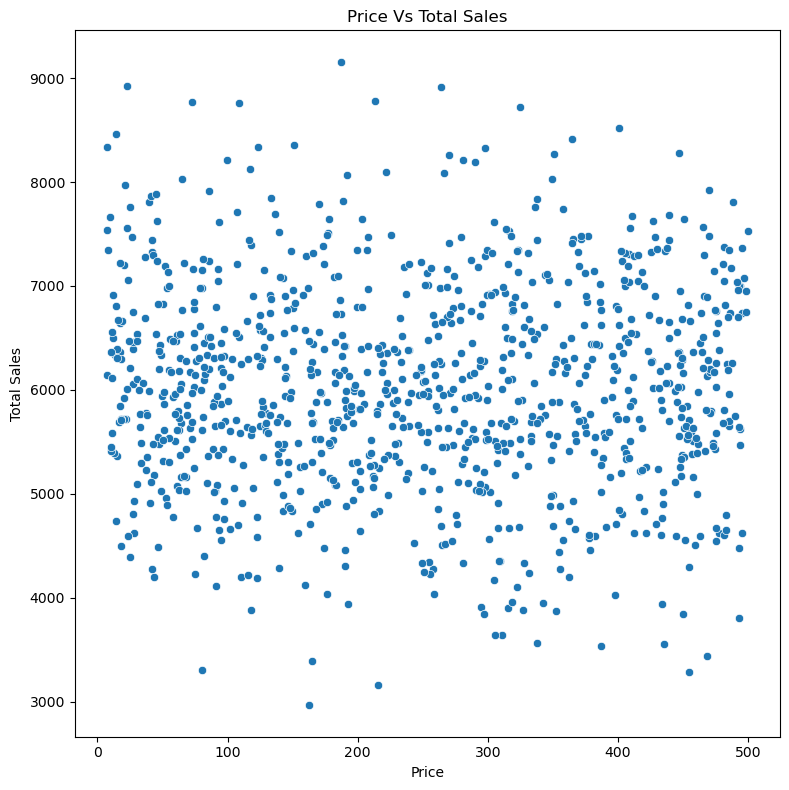

In [27]:
plt.figure(figsize=(8,8))
sns.scatterplot(x="price", y="total_sales", data=df)
plt.title("Price Vs Total Sales")
plt.xlabel("Price")
plt.ylabel("Total Sales")
plt.tight_layout()
plt.show()

<h4><b>Review score vs Sales

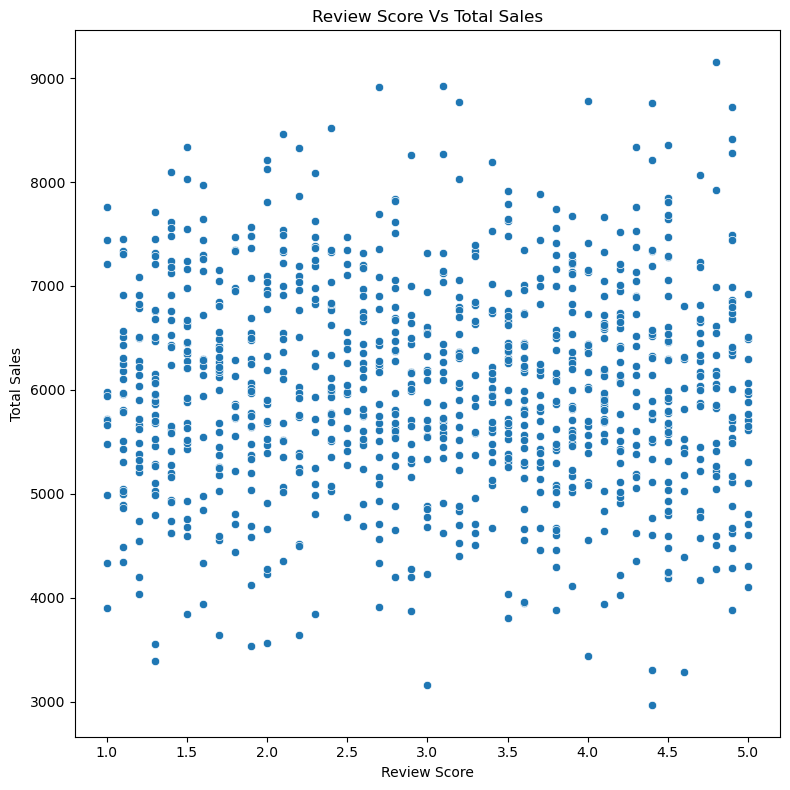

In [32]:
plt.figure(figsize=(8,8))
sns.scatterplot(x="review_score", y="total_sales", data=df)
plt.title("Review Score Vs Total Sales")
plt.xlabel("Review Score")
plt.ylabel("Total Sales")
plt.tight_layout()
plt.show()

<h4><b>Category-wise total sales

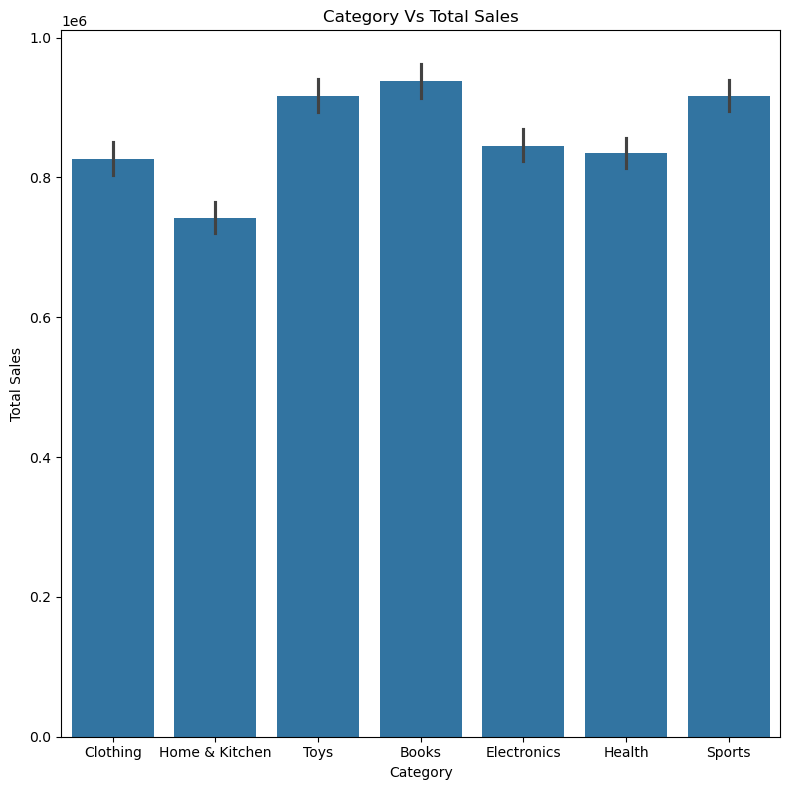

In [31]:
plt.figure(figsize=(8,8))
sns.barplot(x="category", y="total_sales", data=df, estimator=sum)
plt.title("Category Vs Total Sales")
plt.xlabel("Category")
plt.ylabel("Total Sales")
plt.tight_layout()
plt.show()

<h4><b>Correlation heatmap

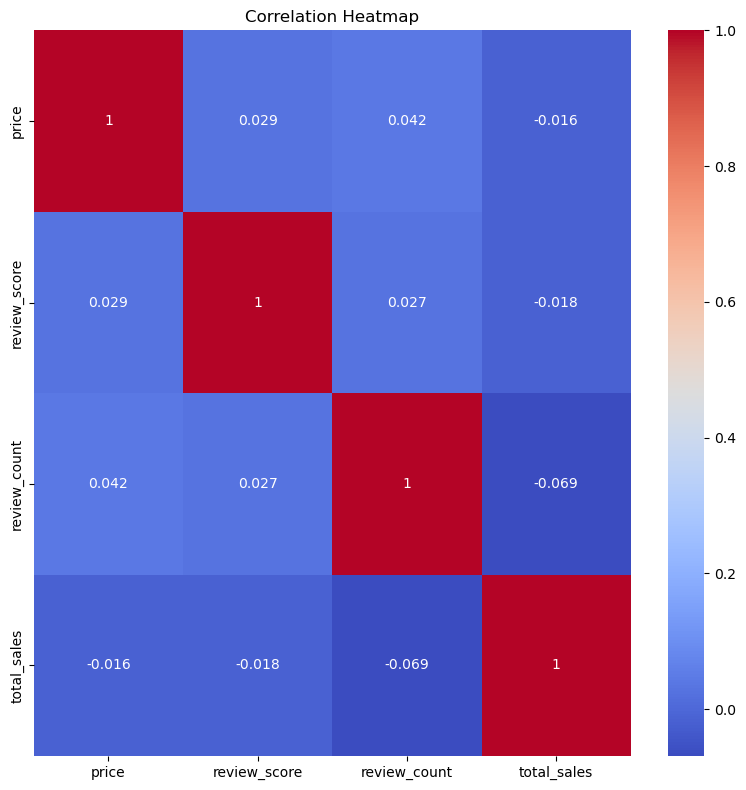

In [30]:
plt.figure(figsize=(8,8))
sns.heatmap(df[["price", "review_score", "review_count", "total_sales"]].corr(), annot=True, cmap="coolwarm")
plt.title("Correlation Heatmap")
plt.tight_layout()
plt.show()

<h3><b>Handling Outliers

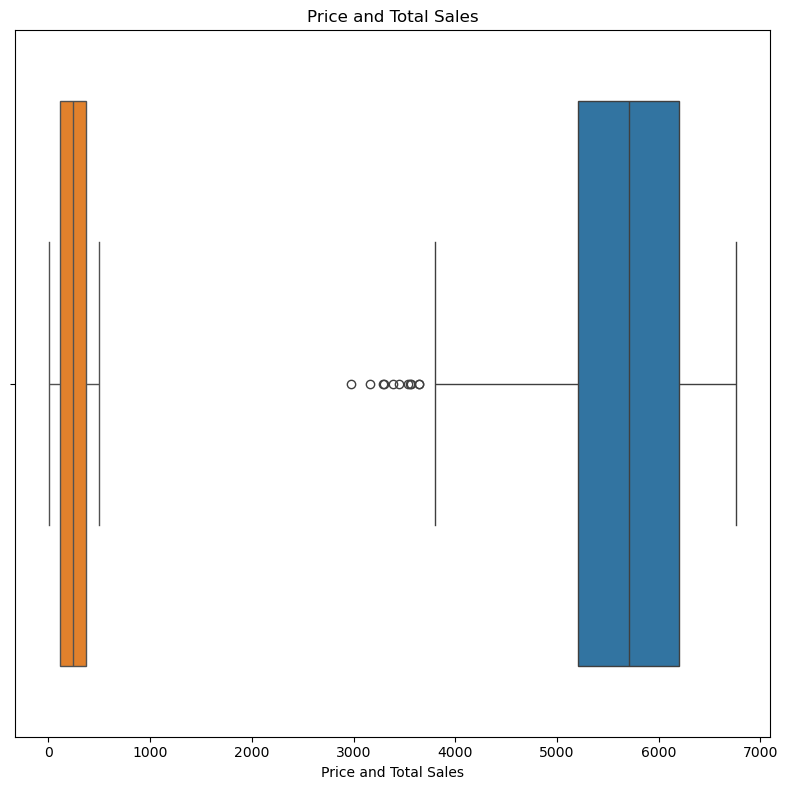

In [44]:
# Remove top 5% extreme sales
df = df[df["total_sales"] < df["total_sales"].quantile(0.95)]
# Boxplot of price and total sales
plt.figure(figsize=(8,8))
sns.boxplot(x=df["total_sales"])
sns.boxplot(x=df["price"])
plt.title("Price and Total Sales")
plt.xlabel("Price and Total Sales")
plt.tight_layout()
plt.show()

<h3><b>Key Insights</b></h3>

<b>1: Positive Relationship Between Price and Sales:</b>
The scatterplot showed that moderately priced products tend to generate higher total sales compared to extremely high- or low-priced items. This indicates that customers prefer products offering balanced value over cost.

<b>2: Review Scores Impact Sales Performance:</b>
The analysis revealed a mild positive correlation between review_score and total_sales, suggesting that products with higher ratings generally attract more customers and drive better sales.

<b>3: Category-Wise Sales Trends:</b>
From the bar chart, a few categories—such as Electronics, Fashion, and Home Appliances—stood out as top performers, contributing the highest total sales. Niche categories showed lower but more stable sales patterns.

<b>4: Price and Sales Variability (Outlier Detection):</b>
Boxplots highlighted several outliers in both price and total_sales, representing premium or bulk-order products. Removing the top 5% extreme values helped achieve a more accurate view of overall sales distribution.

<b>5: Correlation Analysis Summary:</b>
The correlation heatmap showed:

    A moderate positive correlation between price and total_sales.
    A weak negative correlation between price and review_score, indicating that higher-priced products may receive slightly lower reviews.
    A strong link between review_count and total_sales, meaning popular products with more reviews also sell more.

<b>6: Business Implication:</b>
Customers are price-sensitive and highly influenced by product reviews. Businesses should focus on maintaining quality and collecting genuine customer feedback to improve ratings, as these directly support higher sales conversions.

<h3><b>Export Cleaned Dataset

In [40]:
df.to_csv("Cleaned E-Commerce Sales.csv", index=False)